# <font color='dark'>**Classificação: Validação de modelos e métricas de avaliação**</h1>

### Projeto

Uma empresa de empréstimo de automóveis está passando por uma situação complicada, com alta demanda para uma frota reduzida de veículos e alto número de inadimplentes, trazendo um prejuízo grande para a empresa.

Nós fomos contratados para buscar melhorias na identificação de inadimplentes. A análise dos clientes atualmente é feita de forma manual, cliente por cliente, tomando muito tempo e ainda assim a detecção de inadimplentes é muito imprecisa.

Nossa tarefa é utilizar os dados fornecidos pela empresa para **classificar** os clientes em adimplentes e inadimplentes.

## <font color='dark'>Classificando dados</h1>

### Criando um modelo inicial

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv("Dados/emp_automovel.csv")

In [3]:
dados.head()

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.0,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.0,0
1,9000.0,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.0,0
2,15750.0,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.0,0
3,9000.0,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.0,0
4,7650.0,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.0,0


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54025 entries, 0 to 54024
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      54025 non-null  float64
 1   anuidade_emprestimo  54025 non-null  float64
 2   anos_casa_propria    54025 non-null  float64
 3   telefone_trab        54025 non-null  int64  
 4   avaliacao_cidade     54025 non-null  float64
 5   score_1              54025 non-null  float64
 6   score_2              54025 non-null  float64
 7   score_3              54025 non-null  float64
 8   score_social         54025 non-null  float64
 9   troca_telefone       54025 non-null  float64
 10  inadimplente         54025 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


In [5]:
X = dados.drop("inadimplente", axis=1)
y = dados.inadimplente

In [6]:
from sklearn.tree import DecisionTreeClassifier

In [7]:
modelo = DecisionTreeClassifier()
modelo.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
modelo.score(X,y)

1.0

In [9]:
print(f"Acuracia: {modelo.score(X, y)}")

Acuracia: 1.0


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X, X_test, y, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=5)

In [12]:
X_train, X_val, y_train, y_val =train_test_split(X, y, stratify=y, random_state=5)

In [13]:
modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
print(f"Acuracia de treino: {modelo.score(X_train, y_train)}")
print(f"Acuracia de validação: {modelo.score(X_val, y_val)}")

Acuracia de treino: 1.0
Acuracia de validação: 0.8485323578085533


In [15]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
print(f"Acuracia de treino: {modelo.score(X_train, y_train)}")
print(f"Acuracia de validação: {modelo.score(X_val, y_val)}")

Acuracia de treino: 0.9205865272938444
Acuracia de validação: 0.9058444386377493


### Avaliando o modelo

In [17]:
from sklearn.metrics import confusion_matrix

In [18]:
y_previsto = modelo.predict(X_val)

In [ ]:
matriz_confusao = confusion_matrix(y_val, y_previsto)
print(matriz_confusao)

[[10359   120]
 [  961    41]]


In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

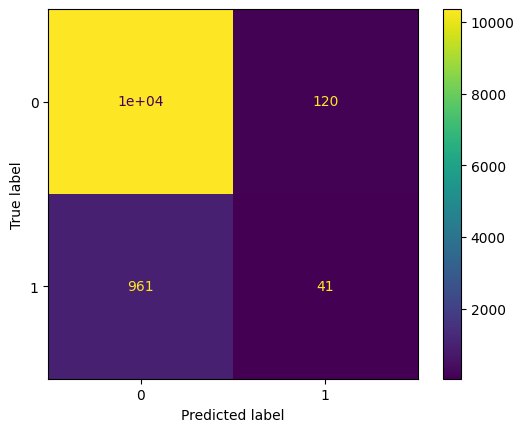

In [21]:
visualicao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
visualicao.plot();

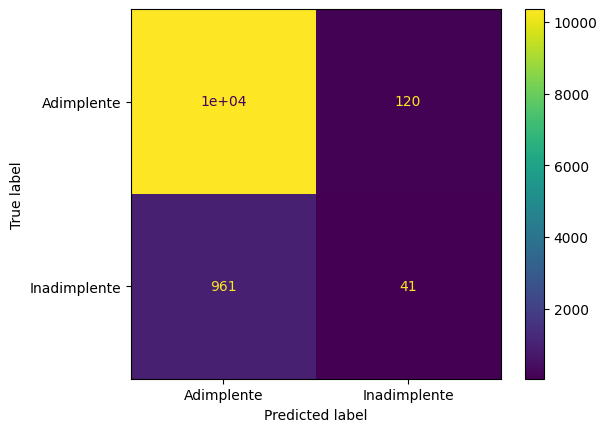

In [22]:
visualicao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=["Adimplente", "Inadimplente"])
visualicao.plot();

# Aula 2  - Metricas de Avalição

In [23]:
from sklearn.metrics import accuracy_score

In [24]:
print(f"Accuracia: {accuracy_score(y_val, y_previsto)}")

Accuracia: 0.9058444386377493


In [25]:
from sklearn.metrics import precision_score, recall_score

In [26]:
print(f"Precisão: {precision_score(y_val, y_previsto)}")
print(f"Recall: {recall_score(y_val, y_previsto)}")


Precisão: 0.2546583850931677
Recall: 0.04091816367265469


In [27]:
from sklearn.metrics import f1_score

In [28]:
print(f"f1_score: {f1_score(y_val, y_previsto)}")

f1_score: 0.0705073086844368


#### Curva ROC

In [ ]:
from sklearn.metrics import RocCurveDisplay

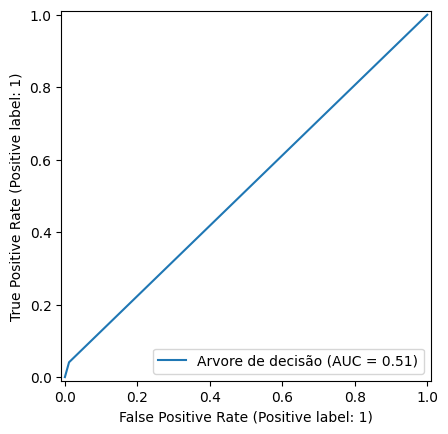

In [30]:
RocCurveDisplay.from_predictions(y_val, y_previsto, name="Arvore de decisão")

In [31]:
from sklearn.metrics import roc_auc_score

In [32]:
print(f"AUC: {roc_auc_score(y_val, y_previsto)}")

AUC: 0.5147333446476644


#### Curva de precisão x recall

In [33]:
from sklearn.metrics import PrecisionRecallDisplay

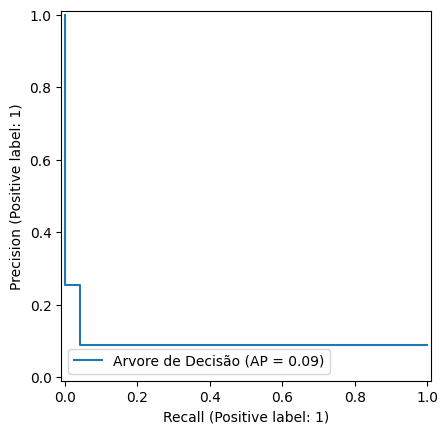

In [34]:
PrecisionRecallDisplay.from_predictions(y_val, y_previsto, name="Arvore de Decisão")

In [35]:
from sklearn.metrics import average_precision_score

In [36]:
print(f"AP: {average_precision_score(y_val, y_previsto)}")


AP: 0.09412366362905589


### Relatório de metricas

In [37]:
from sklearn.metrics import classification_report

In [38]:
print(classification_report(y_val, y_previsto))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.25      0.04      0.07      1002

    accuracy                           0.91     11481
   macro avg       0.58      0.51      0.51     11481
weighted avg       0.86      0.91      0.87     11481



#### Aula 3 - Validação Cruzada

In [39]:
from sklearn.model_selection import cross_validate, KFold

In [40]:
modelo = DecisionTreeClassifier(max_depth=10)

In [43]:
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, X, y, cv=kf)
cv_resultados

{'fit_time': array([0.16574669, 0.20104456, 0.18450332, 0.15996099, 0.15888953]),
 'score_time': array([0.00233102, 0.00256443, 0.00386882, 0.00289774, 0.00210261]),
 'test_score': array([0.91311922, 0.90690331, 0.90777439, 0.91321864, 0.89928136])}

In [ ]:
cv_resultados["test_score"]

array([0.91311922, 0.90690331, 0.90777439, 0.91321864, 0.89928136])

In [47]:
media = cv_resultados["test_score"].mean()
desvio = cv_resultados["test_score"].std()
print(f"O intervalo de confiança é [{media - 2 * desvio}, {min(media + 2 * desvio, 1)}]")

O intervalo de confiança é [0.8978342656615321, 0.918284500923132]


#### Validação cruzada com recall

In [48]:
def intervalo_conf(resultados):
    media = resultados["test_score"].mean()
    desvio = resultados["test_score"].std()
    print(f"O intervalo de confiança é [{media - 2 * desvio}, {min(media + 2 * desvio, 1)}]")

In [49]:
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, X, y, cv=kf, scoring="recall")
cv_resultados

{'fit_time': array([0.16132855, 0.15287852, 0.21132827, 0.14842534, 0.15283513]),
 'score_time': array([0.0121119 , 0.00465345, 0.00853372, 0.01264834, 0.00442648]),
 'test_score': array([0.02906209, 0.01856436, 0.01845018, 0.0156658 , 0.02543353])}

In [50]:
intervalo_conf(cv_resultados)

O intervalo de confiança é [0.011451439382764907, 0.031418940809218435]


#### Estratificando os dados

In [51]:
dados["inadimplente"].value_counts(normalize=True)

inadimplente
0    0.912707
1    0.087293
Name: proportion, dtype: float64

In [52]:
from sklearn.model_selection import StratifiedKFold

In [56]:
modelo = DecisionTreeClassifier(max_depth = 10)
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, X, y, cv = skf, scoring='recall')


In [57]:
intervalo_conf(cv_resultados)

O intervalo de confiança é [0.018925996958889545, 0.03794493432712762]
